# Explorative Data Analyse - Fairytale-Corpus (Grimm)

This notebook provides descriptive statistics of the fairy tale corpus, which consists of three text types:
- **Original**: Original texts by the Brothers Grimm
- **Wikipedia**: Wikipedia summaries of adaptations
- **Copilot**: AI-generated fairy tales based on the Wikipedia summaries

## 1. Setup & Daten laden

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from collections import Counter

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd

# Base directory in Google Drive
base_path = "/content/drive/MyDrive/Märchen-Seminar/Korpus"

rows = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        if not file.endswith(".txt"):
            continue

        path = os.path.join(root, file)

        # Folder structure:
        # .../Korpus/Andersen/Original/FILE.txt
        parts = root.split(os.sep)

        # Author (Andersen / Grimm)
        author = parts[-2] if len(parts) >= 2 else "Unknown"

        # Type (Original / Copilot / Wikipedia)
        text_type = parts[-1] if len(parts) >= 1 else "Other"

        # Parse filename
        # Format: Year_OriginalAuthor_Source_Author_Title.txt
        name = file.replace(".txt", "")
        parts_file = name.split("_")

        year = parts_file[0] if parts_file[0].isdigit() else None
        original_author = parts_file[1] if len(parts_file) > 1 else None
        source = parts_file[2] if len(parts_file) > 2 else None
        author2 = parts_file[3] if len(parts_file) > 3 else None

        # Title = everything from index 4 onward
        title = " ".join(parts_file[4:]) if len(parts_file) > 4 else name

        # Load text
        with open(path, "r", encoding="utf-8") as f:
            text = f.read()

        rows.append({
            "Author": author,
            "Type": text_type,
            "Year": year,
            "OriginalAuthor": original_author,
            "Source": source,
            "Author2": author2,
            "Title": title,
            "Text": text,
            "Filename": file,
            "Path": path
        })

df = pd.DataFrame(rows)
df.to_csv("/content/drive/MyDrive/Märchen-Seminar/Korpus/fairy_tale_corpus_complete.csv", index=False, encoding="utf-8-sig")
df.head()

,Author,Type,Year,OriginalAuthor,Source,Author2,Title,Text,Filename,Path
0,Andersen,Wikipedia,1987,Andersen,Wikipedia,Fleischer,Der kleine und der große Klaus,Der kleine und der große Klaus\n\nIn einem kle...,1987_Andersen_Wikipedia_Fleischer_Der_kleine_u...,/content/drive/MyDrive/Märchen-Seminar/Korpus/...
1,Andersen,Wikipedia,1987,Andersen,Wikipedia,Burrell,Das Mädchen mit den Wunderhölzern,Das Mädchen mit den Wunderhölzern\n\nMolly möc...,1987_Andersen_Wikipedia_Burrell_Das_Mädchen_m...,/content/drive/MyDrive/Märchen-Seminar/Korpus/...
2,Andersen,Wikipedia,1986,Andersen,Wikipedia,Hartzell,Die Schneekönigin,"Die Schneekönigin\n\nEine Prophezeiung besagt,...",1986_Andersen_Wikipedia_Hartzell_Die_Schneekö...,/content/drive/MyDrive/Märchen-Seminar/Korpus/...
3,Andersen,Wikipedia,1968,Andersen,Wikipedia,Dunski,Ein uraltes Märchen,Ein uraltes Märchen\n\nEin armer Puppenspieler...,1968_Andersen_Wikipedia_Dunski_Ein_uraltes_Mä...,/content/drive/MyDrive/Märchen-Seminar/Korpus/...
4,Andersen,Wikipedia,1971,Andersen,Wikipedia,Küchenmeister,Der kleine und der große Klaus,Der kleine und der große Klaus\n\nDer kleine K...,1971_Andersen_Wikipedia_Küchenmeister_Der_kle...,/content/drive/MyDrive/Märchen-Seminar/Korpus/...


In [ ]:
# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Colors per Type
TYPE_COLORS = {
    'Original':  '#4C72B0',
    'Wikipedia': '#DD8452',
    'Copilot':   '#55A868'
}

data_path = '/content/drive/MyDrive/Märchen-Seminar/Korpus/fairy_tale_corpus_complete.csv'

df = pd.read_csv(data_path)
print(f'Load dataset: {df.shape[0]} Rows × {df.shape[1]} Columns')
df.head(3)

Load dataset: 309 Rows × 10 Columns


,Author,Type,Year,OriginalAuthor,Source,Author2,Title,Text,Filename,Path
0,Andersen,Wikipedia,1987,Andersen,Wikipedia,Fleischer,Der kleine und der große Klaus,Der kleine und der große Klaus\n\nIn einem kle...,1987_Andersen_Wikipedia_Fleischer_Der_kleine_u...,/content/drive/MyDrive/Märchen-Seminar/Korpus/...
1,Andersen,Wikipedia,1987,Andersen,Wikipedia,Burrell,Das Mädchen mit den Wunderhölzern,Das Mädchen mit den Wunderhölzern\n\nMolly möc...,1987_Andersen_Wikipedia_Burrell_Das_Mädchen_m...,/content/drive/MyDrive/Märchen-Seminar/Korpus/...
2,Andersen,Wikipedia,1986,Andersen,Wikipedia,Hartzell,Die Schneekönigin,"Die Schneekönigin\n\nEine Prophezeiung besagt,...",1986_Andersen_Wikipedia_Hartzell_Die_Schneekö...,/content/drive/MyDrive/Märchen-Seminar/Korpus/...


## 2. Overview

In [ ]:
print('Texts overall:', len(df))
print('Fairytales unique:', df['Title'].nunique())
print()
print('Distribution of Types:')
print(df['Type'].value_counts().to_frame('Count'))
print()

Texts overall: 309
Fairytales unique: 110

Distribution of Types:
           Count
Type            
Wikipedia    127
Copilot      127
Original      55



In [ ]:
print('Columns and Data types')
print(df.dtypes)
print()
print('Missing values')
print(df.isnull().sum())

Columns and Data types
Author            object
Type              object
Year               int64
OriginalAuthor    object
Source            object
Author2           object
Title             object
Text              object
Filename          object
Path              object
dtype: object

Missing values
Author            0
Type              0
Year              0
OriginalAuthor    0
Source            0
Author2           0
Title             0
Text              0
Filename          0
Path              0
dtype: int64


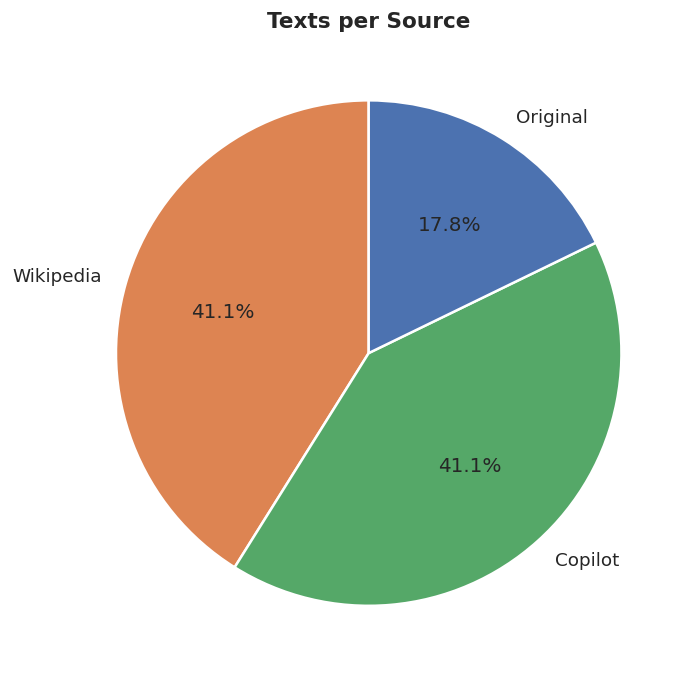

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

# Pie chart for Type
type_counts = df['Type'].value_counts()
colors = [TYPE_COLORS[t] for t in type_counts.index]

ax.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)

ax.set_title('Texts per Source', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
print(pd.crosstab(df["Author"], df["Type"]))

Type      Copilot  Original  Wikipedia
Author                                
Andersen       40        15         40
Grimm          87        40         87


## 3. Feature Engineering - Text metrics

In [ ]:
df['char_count']  = df['Text'].str.len()
df['word_count']  = df['Text'].str.split().str.len()
df['sent_count']  = df['Text'].str.count(r'[.!?]+')
df['para_count']  = df['Text'].str.count(r'\n\n+')
df['avg_word_len'] = df['char_count'] / df['word_count'].replace(0, np.nan)
df['avg_sent_len'] = df['word_count'] / df['sent_count'].replace(0, np.nan)

def ttr(text, window=200):
    tokens = re.findall(r'\b\w+\b', text.lower())
    tokens = tokens[:window]
    if len(tokens) == 0:
        return np.nan
    return len(set(tokens)) / len(tokens)

df['ttr'] = df['Text'].apply(ttr)

print('Added new columns:', ['char_count','word_count','sent_count','para_count','avg_word_len','avg_sent_len','ttr'])
df[['Type','word_count','sent_count','avg_sent_len','ttr']].groupby('Type').mean().round(2)

Added new columns: ['char_count', 'word_count', 'sent_count', 'para_count', 'avg_word_len', 'avg_sent_len', 'ttr']


,word_count,sent_count,avg_sent_len,ttr
Type,,,,
Copilot,546.27,38.93,14.08,0.68
Original,2493.40,128.07,21.12,0.64
Wikipedia,600.83,34.96,17.58,0.65


## 4. Descriptive Statistics of text lengths

In [ ]:
metrics = ['char_count', 'word_count', 'sent_count', 'avg_sent_len', 'ttr']
desc = df.groupby('Type')[metrics].describe().round(2)
desc

char_count                                                        \
               count      mean       std     min     25%      50%      75%   
Type                                                                         
Copilot        127.0   3316.50   1088.37   695.0  2704.5   3535.0   4120.0   
Original        55.0  14585.27  13508.22  2160.0  7172.5  10153.0  14833.5   
Wikipedia      127.0   3797.73   2021.80   403.0  2346.0   3525.0   4795.5   

                   word_count           ... avg_sent_len           ttr        \
               max      count     mean  ...          75%    max  count  mean   
Type                                    ...                                    
Copilot     5733.0      127.0   546.27  ...        15.33  20.54  127.0  0.68   
Original   66275.0       55.0  2493.40  ...        24.23  29.92   55.0  0.64   
Wikipedia  10494.0      127.0   600.83  ...        19.20  24.00  127.0  0.65   

                                               
            std   min   25%   50%   75%   max  
Type                                           
Copilot    0.03  0.57  0.66  0.68  0.70  0.76  
Original   0.04  0.55  0.61  0.64  0.67  0.75  
Wikipedia  0.04  0.52  0.63  0.66  0.68  0.84  

[3 rows x 40 columns]

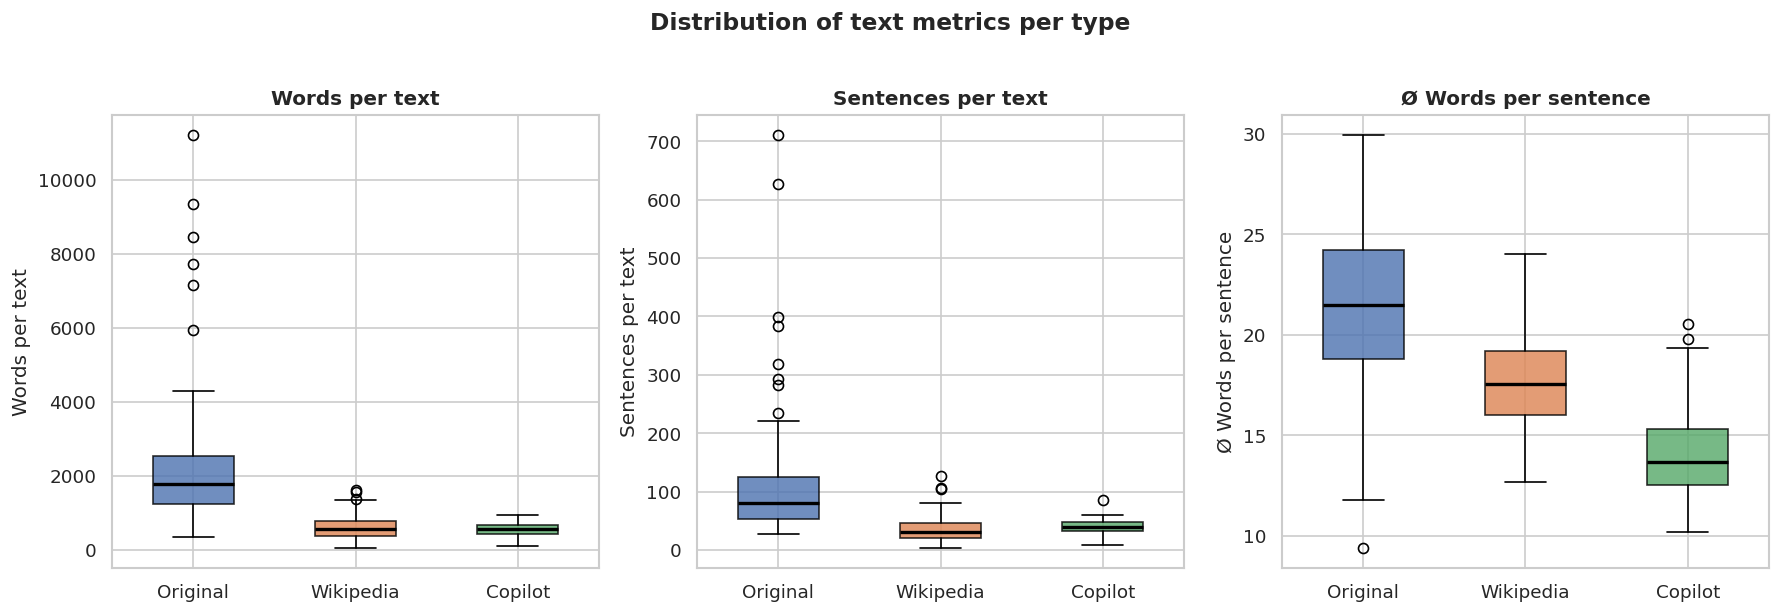

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
type_order = ['Original', 'Wikipedia', 'Copilot']
plot_vars = ['word_count', 'sent_count', 'avg_sent_len']
labels = ['Words per text', 'Sentences per text', 'Ø Words per sentence']

for ax, var, label in zip(axes, plot_vars, labels):
    data = [df[df['Type']==t][var].dropna().values for t in type_order]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    for patch, t in zip(bp['boxes'], type_order):
        patch.set_facecolor(TYPE_COLORS[t])
        patch.set_alpha(0.8)
    ax.set_xticklabels(type_order)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel(label)

plt.suptitle('Distribution of text metrics per type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

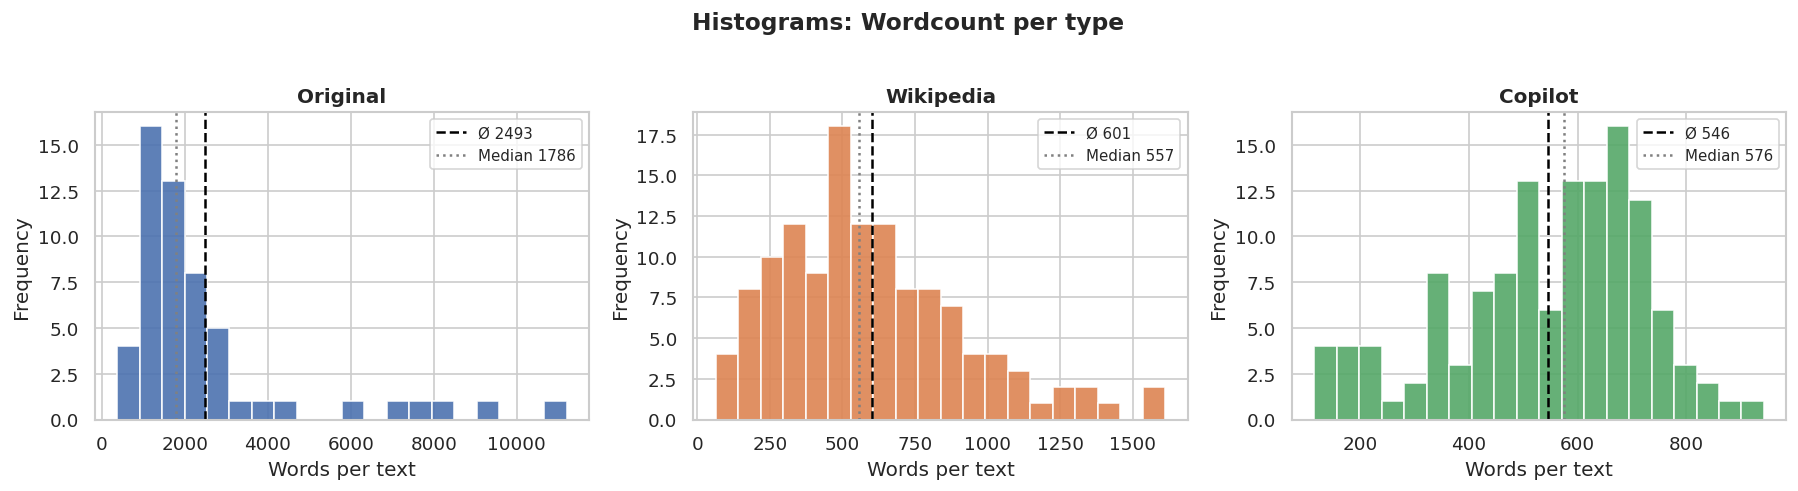

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, t in zip(axes, type_order):
    subset = df[df['Type']==t]['word_count']
    ax.hist(subset, bins=20, color=TYPE_COLORS[t], edgecolor='white', alpha=0.9)
    ax.axvline(subset.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Ø {subset.mean():.0f}')
    ax.axvline(subset.median(), color='grey', linestyle=':', linewidth=1.5, label=f'Median {subset.median():.0f}')
    ax.set_title(f'{t}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Words per text')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Histograms: Wordcount per type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Lexical density (type-token ratio)

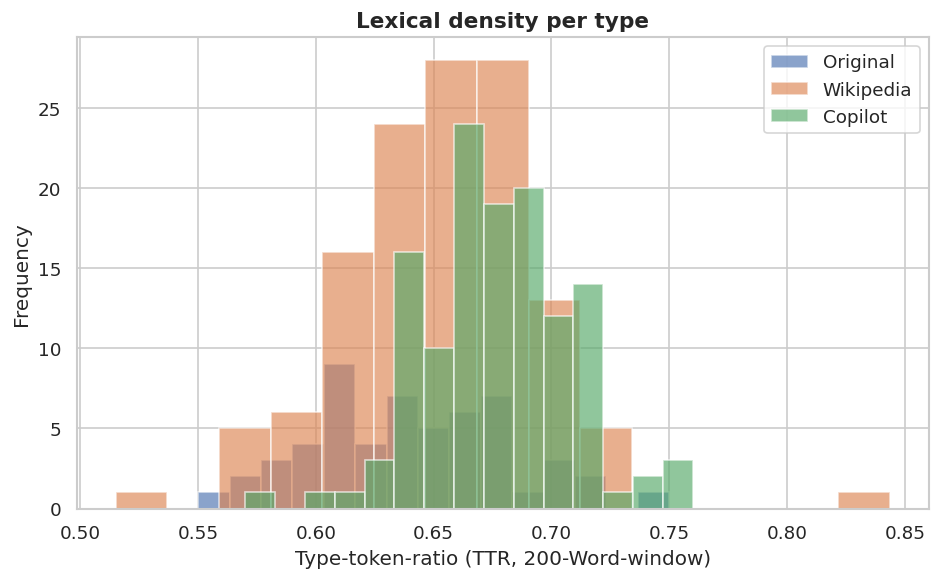


Middle TTR per Type:
Type
Copilot      0.6773
Original     0.6395
Wikipedia    0.6536
Name: ttr, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

for t in type_order:
    vals = df[df['Type']==t]['ttr'].dropna()
    ax.hist(vals, bins=15, alpha=0.65, label=t, color=TYPE_COLORS[t], edgecolor='white')

ax.set_xlabel('Type-token-ratio (TTR, 200-Word-window)')
ax.set_ylabel('Frequency')
ax.set_title('Lexical density per type', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('\nMiddle TTR per Type:')
print(df.groupby('Type')['ttr'].mean().round(4))

## 6. Yearly distribution pf Adaptations (Wikipedia/Copilot)

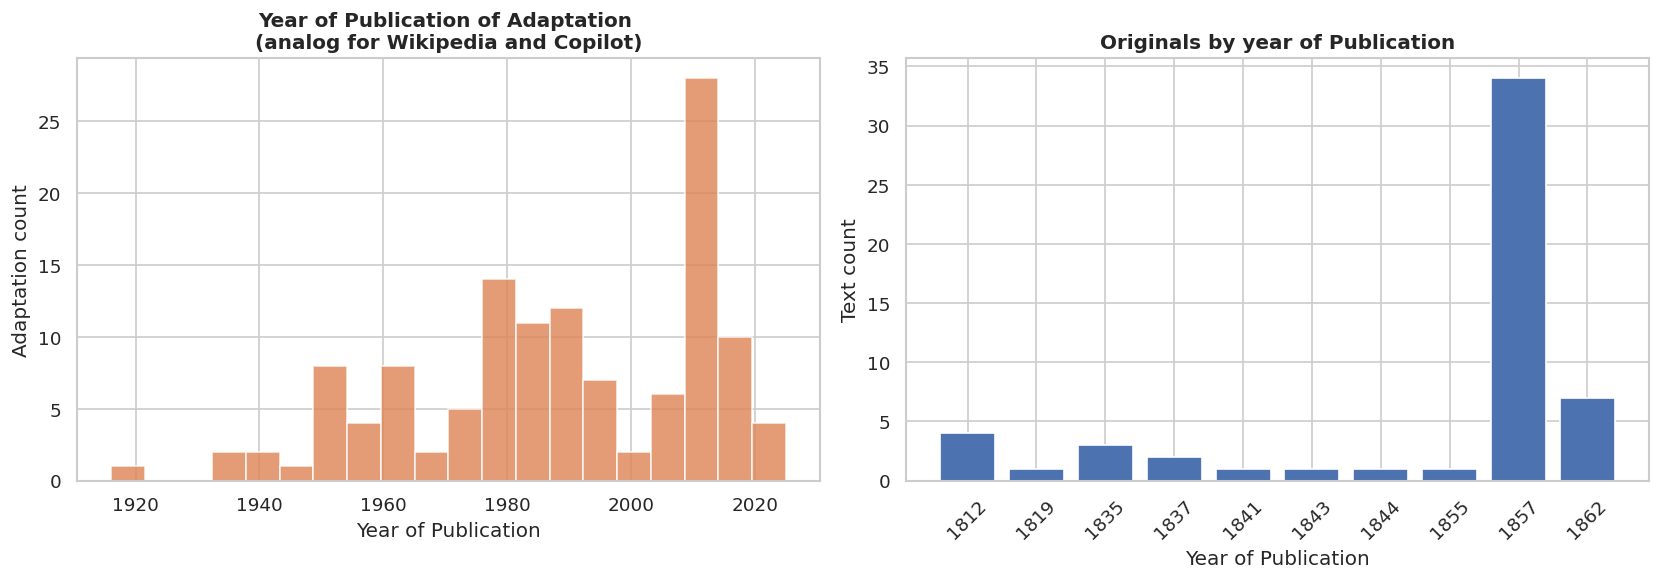

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nur Wikipedia für Jahreszahlen (Copilot hat dasselbe Jahr → wäre doppelt)
wiki = df[df['Type'] == 'Wikipedia'].copy()
axes[0].hist(wiki['Year'].dropna(), bins=20, alpha=0.8,
             color=TYPE_COLORS['Wikipedia'], edgecolor='white')
axes[0].set_xlabel('Year of Publication')
axes[0].set_ylabel('Adaptation count')
axes[0].set_title('Year of Publication of Adaptation \n(analog for Wikipedia and Copilot)',
                  fontsize=12, fontweight='bold')

# Originale nach Jahr
orig_years = df[df['Type'] == 'Original']['Year'].value_counts().sort_index()
axes[1].bar(orig_years.index.astype(str), orig_years.values, color=TYPE_COLORS['Original'])
axes[1].set_xlabel('Year of Publication')
axes[1].set_ylabel('Text count')
axes[1].set_title('Originals by year of Publication', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Title overlaps between types

In [ ]:
orig_titles = set(df[df['Type']=='Original']['Title'])
wiki_titles = set(df[df['Type']=='Wikipedia']['Title'])

print(f'Unique titles – Original:   {len(orig_titles)}')
print(f'Unique titles – Wikipedia/Copilot:  {len(wiki_titles)}')
print()
print(f'Only in Original (no adaptation):  {len(orig_titles - wiki_titles)}')
print(f'In both Original and Wikipedia/Copilot:  {len(orig_titles & wiki_titles)}')
print(f'Only in Wikipedia/Copilot (no Original):  {len(wiki_titles - orig_titles)}')
print()
print('Tales only in Original (no adaptation in corpus):')
print(sorted(orig_titles - wiki_titles))

Unique titles – Original:   55
Unique titles – Wikipedia/Copilot:  87

Only in Original (no adaptation):  19
In both Original and Wikipedia/Copilot:  36
Only in Wikipedia/Copilot (no Original):  51

Tales only in Original (no adaptation in corpus):
['Das hässliche junge Entlein', 'Das kleine Mädchen mit den Schwefelhölzern', 'Das singende springende Löweneckerchen', 'Der Froschkönig oder der eiserne Heinrich', 'Der Gevatter Tod', 'Der Töpelhans', 'Der Wolf und die sieben jungen Geißlein', 'Der kleine Klaus und der grosse Klaus', 'Die Goldkinder', 'Die Krystallkugel', 'Die kleine Seejungfer', 'Die sechs Schwaene', 'Die zwei Brüder', 'Hänsel und Grethel', 'Rapunzel', 'Rothkäppchen', 'Rumpelstilzchen', 'Schneeweißchen und Rosenroth', 'Sneewittchen']


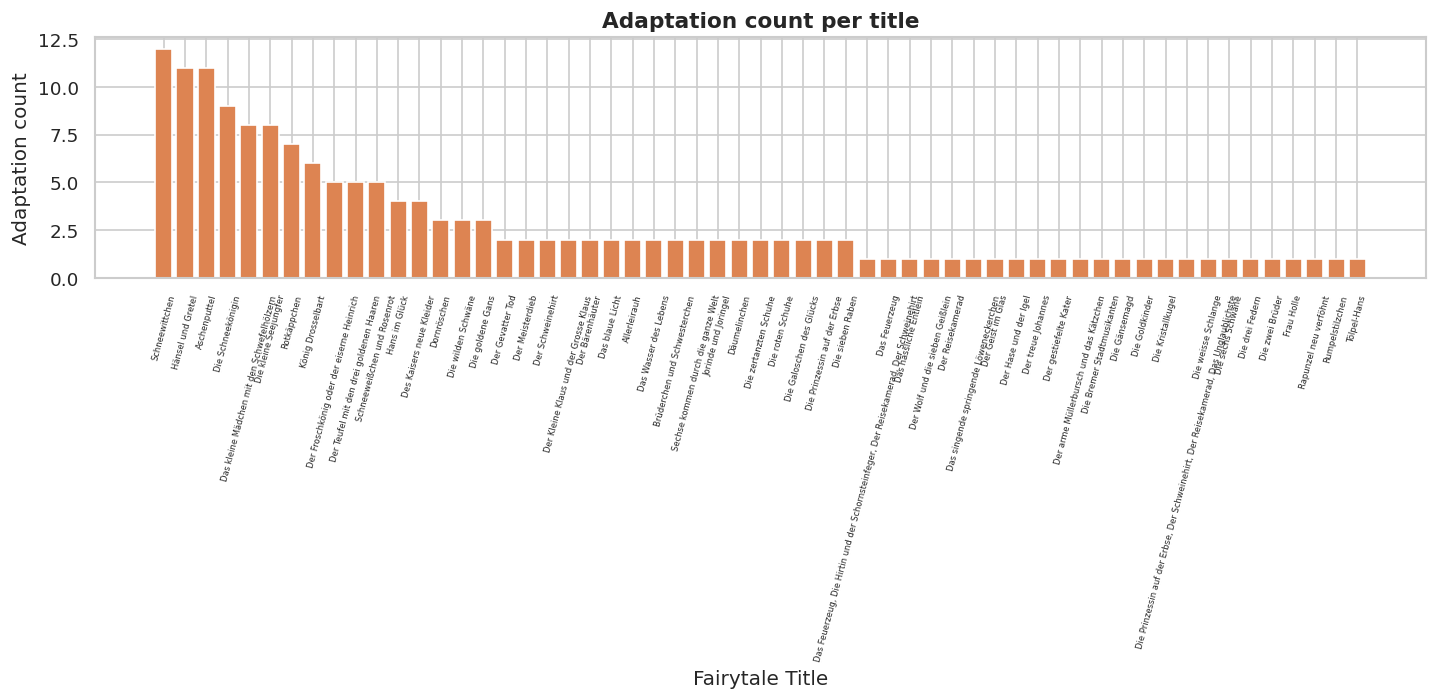

In [ ]:
meta1 = pd.read_excel("/content/drive/MyDrive/Märchen-Seminar/Korpus/Metadata_Fairytale_Corpus.xlsx", sheet_name="Adaptationen(Wikipedia)_Grimm")
meta2 = pd.read_excel("/content/drive/MyDrive/Märchen-Seminar/Korpus/Metadata_Fairytale_Corpus.xlsx", sheet_name="Adaptationen(Wikipedia)_Anderse")
meta = pd.concat([meta1, meta2], ignore_index=True)

# How many Adaptations per original title?
adaption_counts = meta.groupby('Original Title (Grimm)').size().reset_index(name='n_adaptions')
adaption_counts = adaption_counts.sort_values('n_adaptions', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(adaption_counts['Original Title (Grimm)'], adaption_counts['n_adaptions'], color='#DD8452', edgecolor='white')
ax.set_xlabel('Fairytale Title')
ax.set_ylabel('Adaptation count')
ax.set_title('Adaptation count per title', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=75, labelsize=5)
plt.tight_layout()
plt.show()

## 8. Comparison original vs. adaptation: text length per title

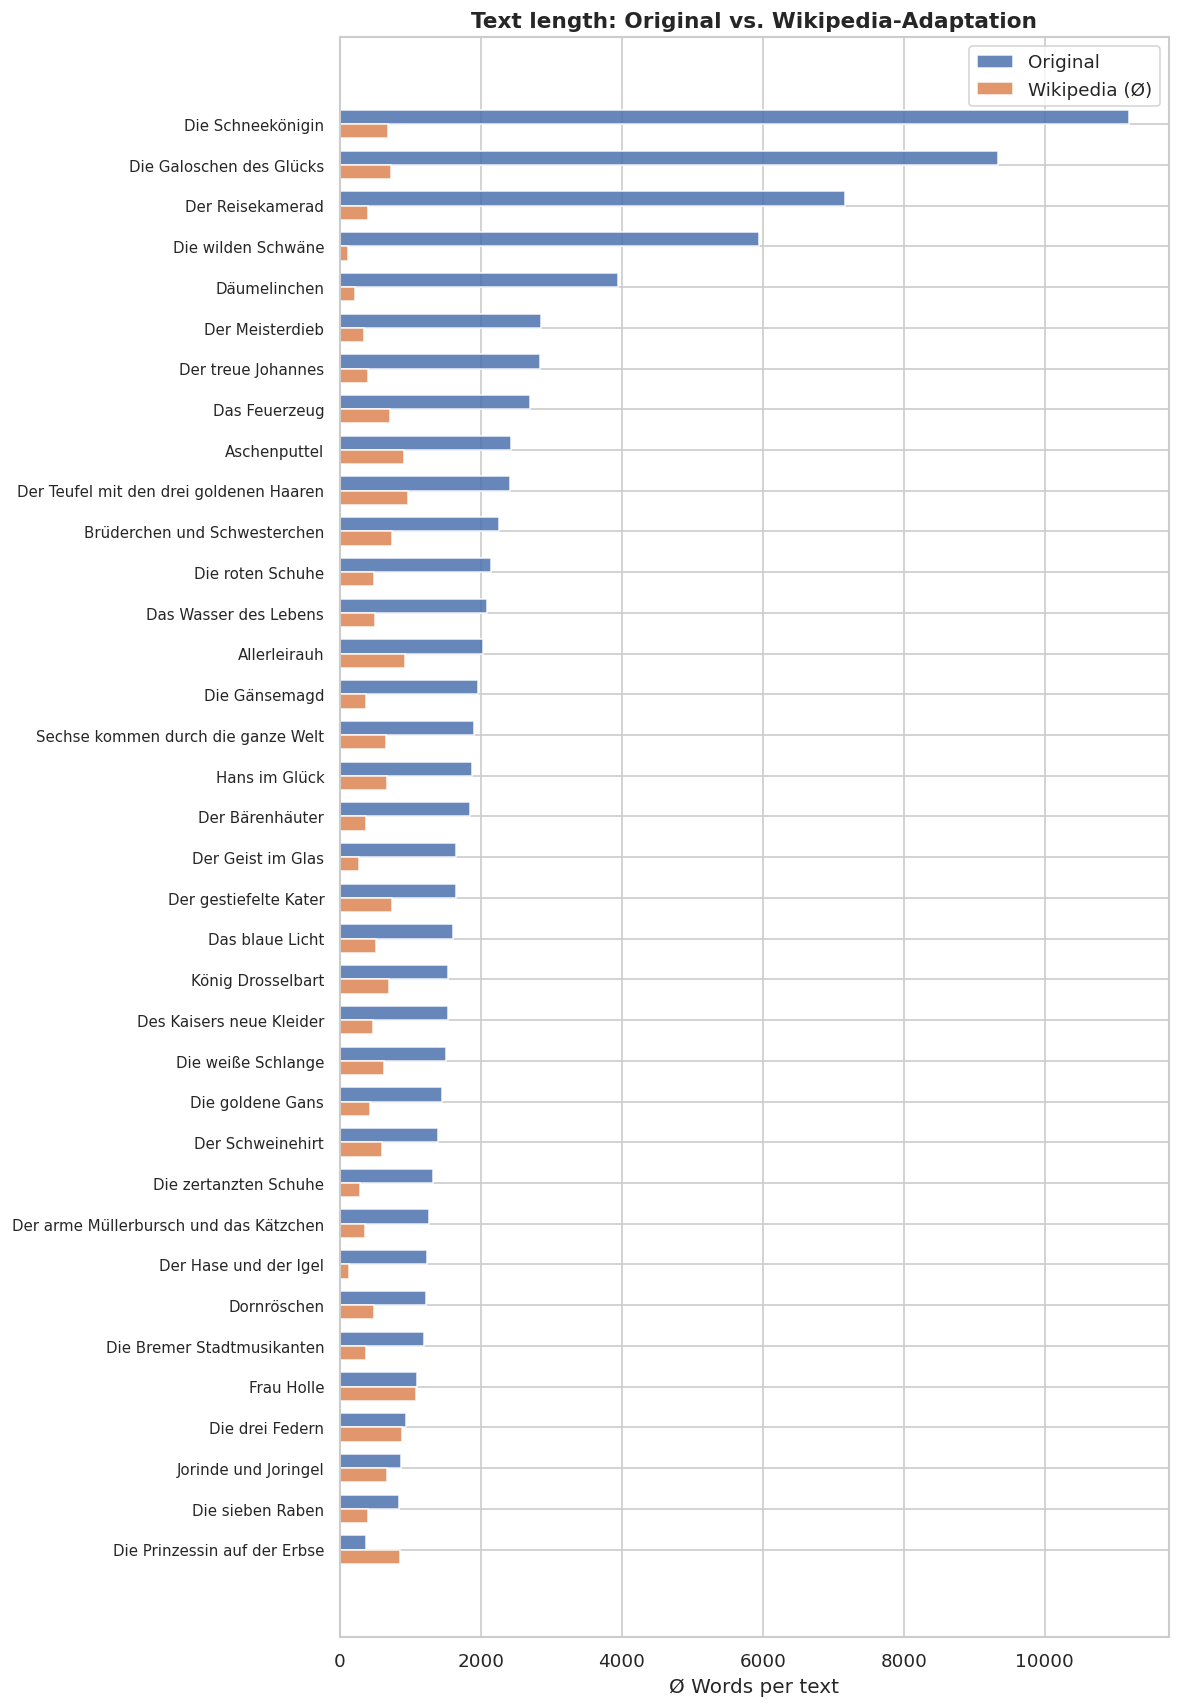

In [ ]:
mean_words = df.groupby(['Title','Type'])['word_count'].mean().reset_index()
pivot = mean_words.pivot(index='Title', columns='Type', values='word_count')

both = pivot.dropna(subset=['Original','Wikipedia']).copy()
both = both.sort_values('Original', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(both)*0.4)))
y = range(len(both))
bar_width = 0.35
ax.barh([i + bar_width/2 for i in y], both['Original'], bar_width,
        label='Original', color=TYPE_COLORS['Original'], alpha=0.85)
ax.barh([i - bar_width/2 for i in y], both['Wikipedia'], bar_width,
        label='Wikipedia (Ø)', color=TYPE_COLORS['Wikipedia'], alpha=0.85)
ax.set_yticks(list(y))
ax.set_yticklabels(both.index, fontsize=9)
ax.set_xlabel('Ø Words per text')
ax.set_title('Text length: Original vs. Wikipedia-Adaptation', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
fig.savefig("figure_b_length_comparison.jpg", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
fig.savefig("figure_b_length_comparison.jpg", dpi=300, bbox_inches='tight')

## 9. Scatter plot and correlation matrix

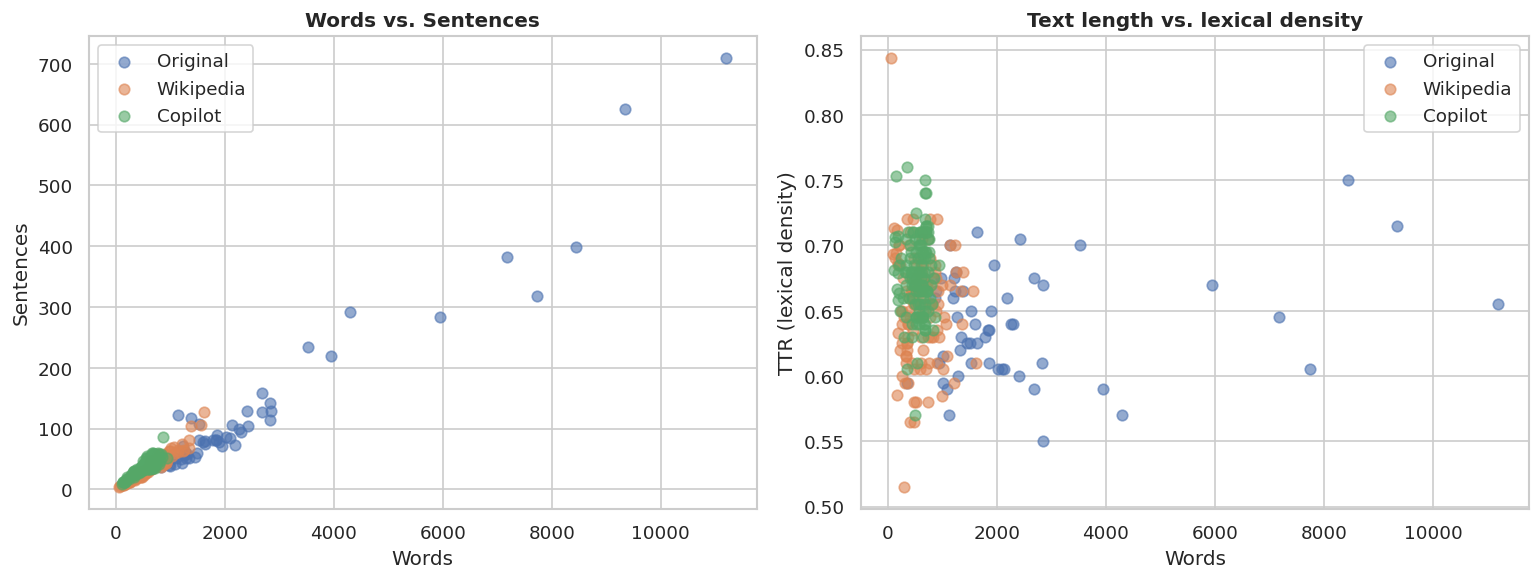

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for t in type_order:
    sub = df[df['Type']==t]
    axes[0].scatter(sub['word_count'], sub['sent_count'],
                    alpha=0.6, label=t, color=TYPE_COLORS[t], s=40)
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Sentences')
axes[0].set_title('Words vs. Sentences', fontsize=12, fontweight='bold')
axes[0].legend()

for t in type_order:
    sub = df[df['Type']==t]
    axes[1].scatter(sub['word_count'], sub['ttr'],
                    alpha=0.6, label=t, color=TYPE_COLORS[t], s=40)
axes[1].set_xlabel('Words')
axes[1].set_ylabel('TTR (lexical density)')
axes[1].set_title('Text length vs. lexical density', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

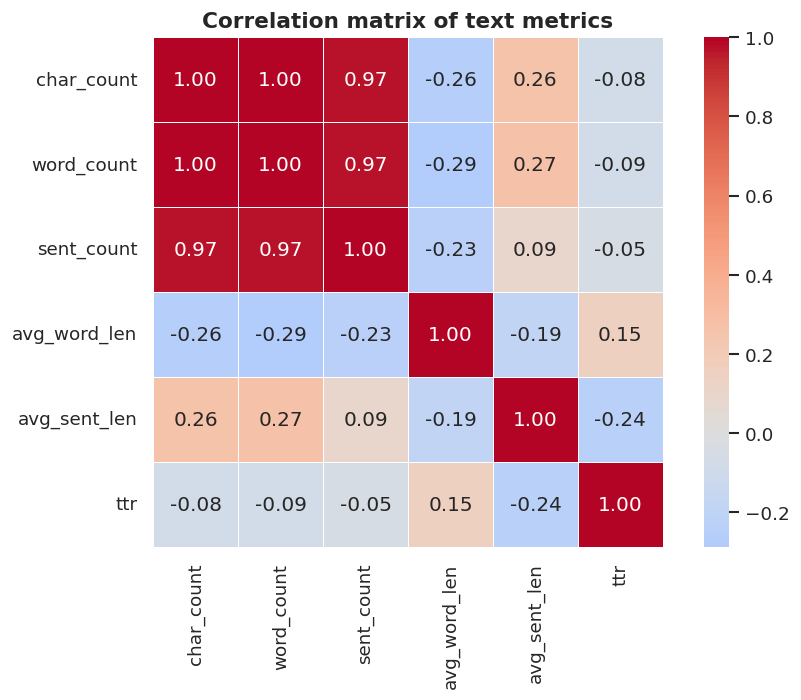

In [ ]:
num_cols = ['char_count','word_count','sent_count','avg_word_len','avg_sent_len','ttr']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, square=True)
ax.set_title('Correlation matrix of text metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Most frequent content words per type (without stopwords)

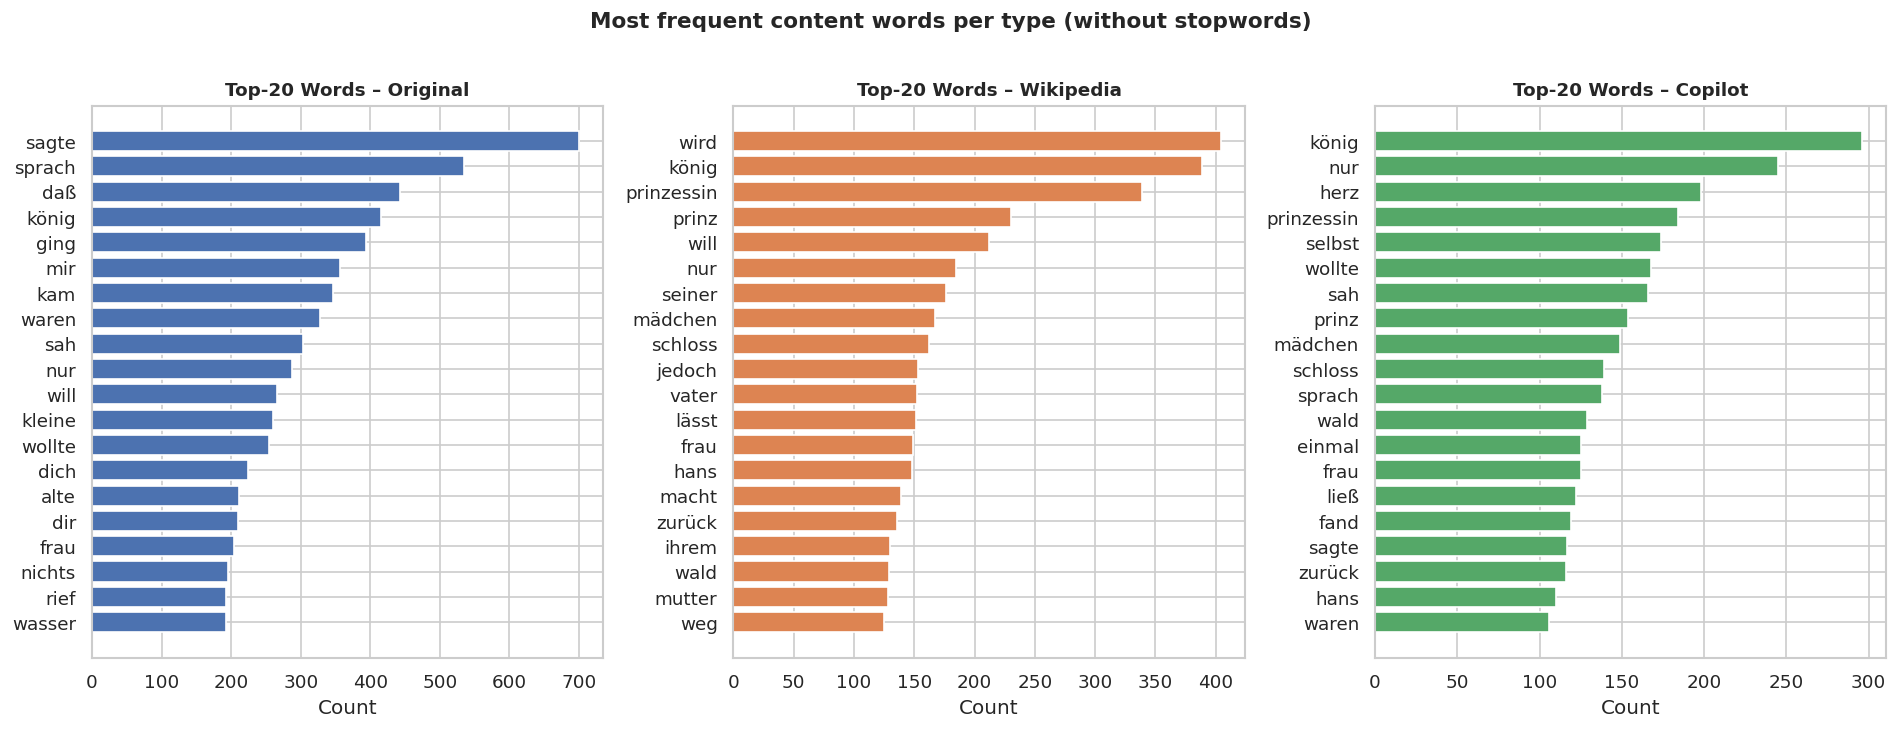

In [ ]:
# Simple german stopwords list
STOPWORDS = set([
    'der','die','das','und','in','zu','den','von','mit','ist','im','ein',
    'eine','einer','einen','einem','eines','sie','er','es','auf','dem',
    'an','sich','des','als','sich','aber','auch','war','nicht','so',
    'noch','wenn','hatte','worden','worden','werden','wurde','haben',
    'sein','ihre','ihren','ihrer','diesem','dieser','dieses','wie','dass',
    'ihn','ihm','ich','du','wir','ihr','uns','euch','doch','mehr','nun',
    'habe','durch','nach','bei','vor','für','aus','oder','zum','zur',
    'um','dann','schon','da','ja','man','hat','ob','bei','bis','sind',
    'seine','seinem','seinen','ihnen','ihn','kann','konnte','wo','über',
    'diesen','diesem','diese','solche','solcher','solches','da',
    'alle','alles','keine','kein','keinen','keinem','keiner','kein',
    'denn','mich','mein','meinen','meiner','meinem','meines',
    'dein','deinen','deiner','deinem','deines','sehr','ganz','zu',
    'wieder','wer','wem','wen','was','wann','hier','dort','hin','her',
    'hinaus','herein','dazu','dabei','dafür','damit','danach','daran',
])

def top_words(texts, n=20):
    all_tokens = []
    for text in texts:
        tokens = re.findall(r'\b[a-zA-ZäöüÄÖÜß]{3,}\b', text.lower())
        all_tokens.extend([t for t in tokens if t not in STOPWORDS])
    return Counter(all_tokens).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, t in zip(axes, type_order):
    texts = df[df['Type']==t]['Text'].dropna().tolist()
    words, counts = zip(*top_words(texts, 20))
    ax.barh(words[::-1], counts[::-1], color=TYPE_COLORS[t], edgecolor='white')
    ax.set_title(f'Top-20 Words – {t}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Count')

plt.suptitle('Most frequent content words per type (without stopwords)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Summary

In [ ]:
summary = df.groupby('Type').agg(
    Anzahl_Texte       = ('Title', 'count'),
    Eindeutige_Titel   = ('Title', 'nunique'),
    Jahr_Min           = ('Year', 'min'),
    Jahr_Max           = ('Year', 'max'),
    Ø_Wörter           = ('word_count', 'mean'),
    Med_Wörter         = ('word_count', 'median'),
    Ø_Sätze            = ('sent_count', 'mean'),
    Ø_WörterProSatz    = ('avg_sent_len', 'mean'),
    Ø_TTR              = ('ttr', 'mean'),
).round(2)

print('Summary of fairytale corpus')
summary

Summary of fairytale corpus


,Anzahl_Texte,Eindeutige_Titel,Jahr_Min,Jahr_Max,Ø_Wörter,Med_Wörter,Ø_Sätze,Ø_WörterProSatz,Ø_TTR
Type,,,,,,,,,
Copilot,127,88,1916,2025,546.27,576.0,38.93,14.08,0.68
Original,55,55,1812,1862,2493.40,1786.0,128.07,21.12,0.64
Wikipedia,127,87,1916,2025,600.83,557.0,34.96,17.58,0.65


In [ ]:
print('Additional observations')
print()

orig_mean = df[df['Type']=='Original']['word_count'].mean()
wiki_mean = df[df['Type']=='Wikipedia']['word_count'].mean()
cop_mean  = df[df['Type']=='Copilot']['word_count'].mean()

print(f'Originals are on average {orig_mean/wiki_mean:.1f} times as long as Wikipedia summaries.')
print(f'Copilot-Texts are on average {cop_mean/wiki_mean:.1f}times as long as Wikipedia summaries.')
print()

n_with_orig  = len(set(df[df['Type']=='Wikipedia']['Title']) & set(df[df['Type']=='Original']['Title']))
n_only_wiki  = len(set(df[df['Type']=='Wikipedia']['Title']) - set(df[df['Type']=='Original']['Title']))
print(f'{n_with_orig} Fairy tale titles have both an original and a Wikipedia adaptation in the corpus.')
print(f'{n_only_wiki} Wikipedia-Adaptations have no original fairytale in the corpus.')

longest = df.loc[df['word_count'].idxmax()]
shortest = df.loc[df['word_count'].idxmin()]
print()
print(f'Longest Text:  "{longest.Title}" ({longest.Type}, {longest.word_count} Words)')
print(f'Shortest Text: "{shortest.Title}" ({shortest.Type}, {shortest.word_count} Words)')

Additional observations

Originals are on average 4.1 times as long as Wikipedia summaries.
Copilot-Texts are on average 0.9times as long as Wikipedia summaries.

36 Fairy tale titles have both an original and a Wikipedia adaptation in the corpus.
51 Wikipedia-Adaptations have no original fairytale in the corpus.

Longest Text:  "Die Schneekönigin" (Original, 11200 Words)
Shortest Text: "Die wilden Schwäne" (Wikipedia, 64 Words)
